<a href="https://colab.research.google.com/github/bishal5590/AOSC/blob/main/Third_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import shap

from scipy.stats import gmean

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay

In [ ]:
#Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

Import data from files

In [ ]:
data = pd.read_csv("family_level_5.csv")
# Binary label
y = data["Weight.1"].astype(int).values

# Microbiota features only
X_df = data.drop(columns=["Weight", "Weight.1"])

In [ ]:
print("X shape:", X_df.shape)
print("y shape:", y.shape)
print("Class counts:\n", pd.Series(y).value_counts())

X shape: (39, 74)
y shape: (39,)
Class counts:
 0    20
1    19
Name: count, dtype: int64


Lets define function "**build_model**"

In [ ]:

def build_model(input_dim):
    lr_schedule = CosineDecay(
        initial_learning_rate=0.005,
        decay_steps=1000,
        alpha=0.0001
    )

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(
            8,
            activation='relu',
            kernel_regularizer=regularizers.l2(0.001)
        ),
        Dropout(0.3),
        Dense(
            4,
            activation='relu',
            kernel_regularizer=regularizers.l2(0.001)
        ),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    optimizer = AdamW(
        learning_rate=lr_schedule,
        weight_decay=1e-4,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

Pre-fold preprocessing" **microbiome_preprocess_train_test**"

In [ ]:

def microbiome_preprocess_train_test(X_train_raw, X_test_raw):
    # Relative abundance
    X_train_rel = X_train_raw.div(X_train_raw.sum(axis=1), axis=0)
    X_test_rel = X_test_raw.div(X_test_raw.sum(axis=1), axis=0)

    # Filter using training set only
    occurrence = (X_train_rel > 0).sum(axis=0) / X_train_rel.shape[0]
    mean_abundance = X_train_rel.mean(axis=0)
    mask = ~((occurrence < 0.05) & (mean_abundance < 0.0001))

    X_train_filt = X_train_rel.loc[:, mask]
    X_test_filt = X_test_rel.loc[:, mask]

    # CLR
    X_train_pseudo = X_train_filt + 1e-6
    X_test_pseudo = X_test_filt + 1e-6

    gm_train = gmean(X_train_pseudo, axis=1)
    gm_test = gmean(X_test_pseudo, axis=1)

    X_train_clr = np.log(X_train_pseudo.div(gm_train, axis=0))
    X_test_clr = np.log(X_test_pseudo.div(gm_test, axis=0))

    return X_train_clr, X_test_clr

In [ ]:
# 5. Stratified K-fold CV

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)

fold_metrics = []
all_conf_matrices = []
nn_histories = []
# store last fold objects for SHAP
last_model = None
last_X_test_scaled = None
last_feature_names = None
last_y_test = None

for fold, (train_idx, test_idx) in enumerate(skf.split(X_df, y), start=1):
    print(f"\n{'='*20} Fold {fold} {'='*20}")

    # raw split
    X_train_raw = X_df.iloc[train_idx].copy()
    X_test_raw = X_df.iloc[test_idx].copy()
    y_train = y[train_idx]
    y_test = y[test_idx]

    # preprocess inside fold
    X_train_clr, X_test_clr = microbiome_preprocess_train_test(X_train_raw, X_test_raw)
    # RF feature selection on training only
    rf = RandomForestClassifier(
    n_estimators=500,
    random_state=seed
)
    rf.fit(X_train_clr, y_train)
    importances = pd.Series(rf.feature_importances_, index=X_train_clr.columns)
    importances_sorted = importances.sort_values(ascending=False)
    # Select taxa explaining ≥ 90% of RF importance
    cum_frac = importances_sorted.cumsum() / importances_sorted.sum()
    top_n_count = np.searchsorted(cum_frac.values, 0.90) + 1
    print(f"Fold {fold}: selected {top_n_count} taxa to reach 90% RF importance.")
    top_features = importances_sorted.head(top_n_count).index

    X_train_top = X_train_clr.loc[:, top_features]
    X_test_top  = X_test_clr.loc[:, top_features]
    # scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_top)
    X_test_scaled = scaler.transform(X_test_top)

    # inner validation split for early stopping
    X_train_inner, X_val, y_train_inner, y_val = train_test_split(
        X_train_scaled,
        y_train,
        test_size=0.2,
        random_state=seed,
        stratify=y_train
    )

    # build/train model
    model = build_model(input_dim=X_train_inner.shape[1])

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_inner,
        y_train_inner,
        validation_data=(X_val, y_val),
        epochs=70,
        batch_size=8,
        callbacks=[early_stop],
        verbose=0
    )
    nn_histories.append(history.history)

    # predictions on held-out fold
    y_prob = model.predict(X_test_scaled, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    # metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    fold_metrics.append({
        "fold": fold,
        "accuracy": acc,
        "roc_auc": auc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })
    all_conf_matrices.append(cm)

    print(f"Accuracy : {acc:.3f}")
    print(f"ROC AUC  : {auc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1       : {f1:.3f}")
    print("Confusion matrix:")
    print(cm)

    # save last fold objects for SHAP demo
    last_model = model
    last_X_test_scaled = X_test_scaled
    last_feature_names = list(top_features)
    last_y_test = y_test


==================== Fold 1 ====================
Fold 1: selected 34 taxa to reach 90% RF importance.
Accuracy : 1.000
ROC AUC  : 1.000
Precision: 1.000
Recall   : 1.000
F1       : 1.000
Confusion matrix:
[[4 0]
 [0 4]]

==================== Fold 2 ====================
Fold 2: selected 34 taxa to reach 90% RF importance.
Accuracy : 0.750
ROC AUC  : 0.938
Precision: 0.750
Recall   : 0.750
F1       : 0.750
Confusion matrix:
[[3 1]
 [1 3]]

==================== Fold 3 ====================
Fold 3: selected 37 taxa to reach 90% RF importance.
Accuracy : 0.875
ROC AUC  : 1.000
Precision: 1.000
Recall   : 0.750
F1       : 0.857
Confusion matrix:
[[4 0]
 [1 3]]

==================== Fold 4 ====================
Fold 4: selected 35 taxa to reach 90% RF importance.
Accuracy : 0.875
ROC AUC  : 1.000
Precision: 0.800
Recall   : 1.000
F1       : 0.889
Confusion matrix:
[[3 1]
 [0 4]]

==================== Fold 5 ====================
Fold 5: selected 39 taxa to reach 90% RF importance.


Accuracy : 1.000
ROC AUC  : 1.000
Precision: 1.000
Recall   : 1.000
F1       : 1.000
Confusion matrix:
[[4 0]
 [0 3]]


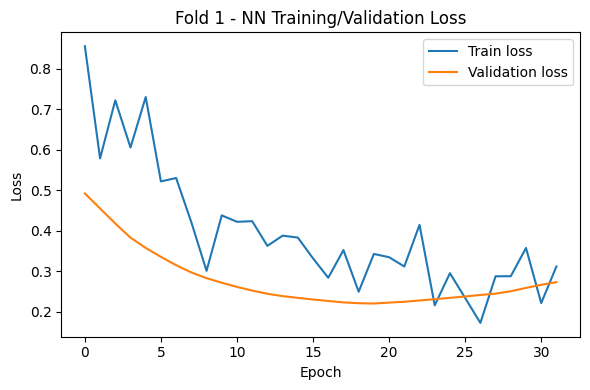

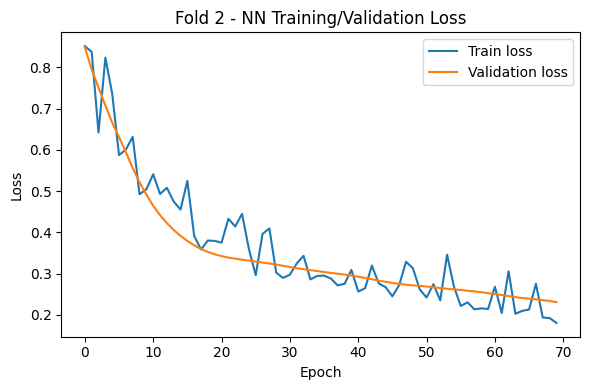

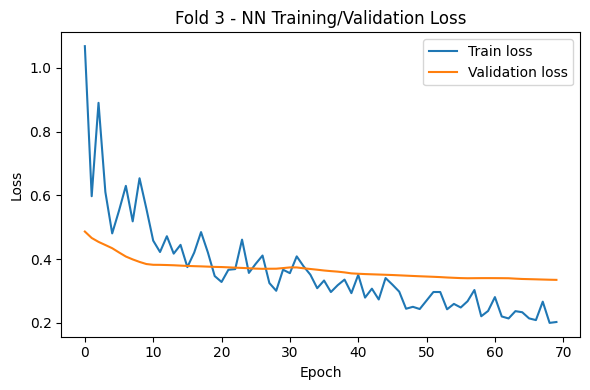

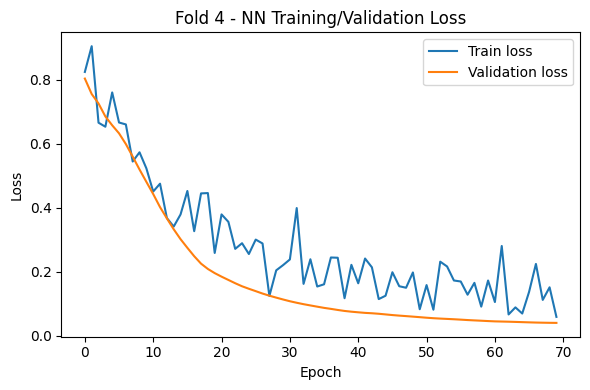

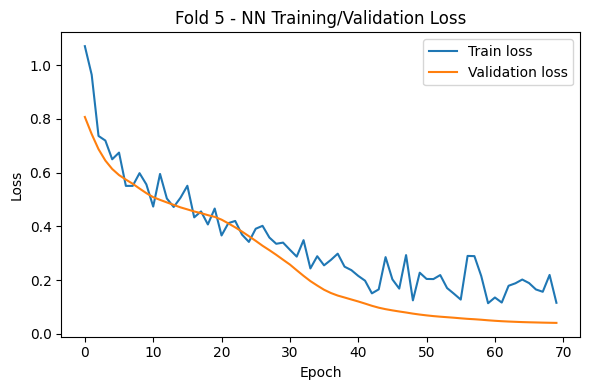

In [ ]:
#Plot NN loss curves for all folds

for i, hist in enumerate(nn_histories, start=1):
    plt.figure(figsize=(6, 4))
    plt.plot(hist["loss"], label="Train loss")
    plt.plot(hist["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {i} - NN Training/Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


Per-fold metrics:
   fold  accuracy  roc_auc  precision  recall        f1
0     1     1.000   1.0000       1.00    1.00  1.000000
1     2     0.750   0.9375       0.75    0.75  0.750000
2     3     0.875   1.0000       1.00    0.75  0.857143
3     4     0.875   1.0000       0.80    1.00  0.888889
4     5     1.000   1.0000       1.00    1.00  1.000000

Mean metrics across folds:
accuracy     0.900
roc_auc      0.988
precision    0.910
recall       0.900
f1           0.899
dtype: float64

SD across folds:
accuracy     0.105
roc_auc      0.028
precision    0.124
recall       0.137
f1           0.105
dtype: float64

Summed confusion matrix across all folds:
[[18  2]
 [ 2 17]]


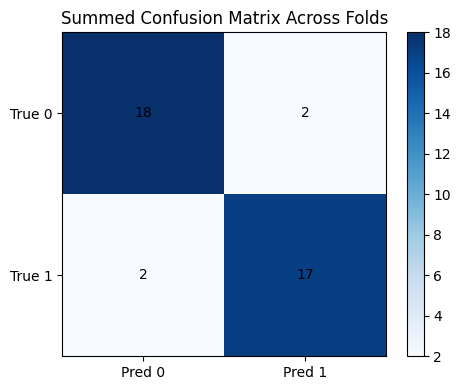

In [ ]:
# 6. Summary across folds

metrics_df = pd.DataFrame(fold_metrics)

print("\nPer-fold metrics:")
print(metrics_df)

print("\nMean metrics across folds:")
print(metrics_df[["accuracy", "roc_auc", "precision", "recall", "f1"]].mean().round(3))

print("\nSD across folds:")
print(metrics_df[["accuracy", "roc_auc", "precision", "recall", "f1"]].std().round(3))

# summed confusion matrix across folds
total_cm = np.sum(all_conf_matrices, axis=0)
print("\nSummed confusion matrix across all folds:")
print(total_cm)

# optional: plot aggregated confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(total_cm, cmap="Blues")
plt.title("Summed Confusion Matrix Across Folds")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, total_cm[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

# SHAP

  0%|          | 0/7 [00:00<?, ?it/s]

/tmp/ipykernel_5451/1923210315.py:33: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


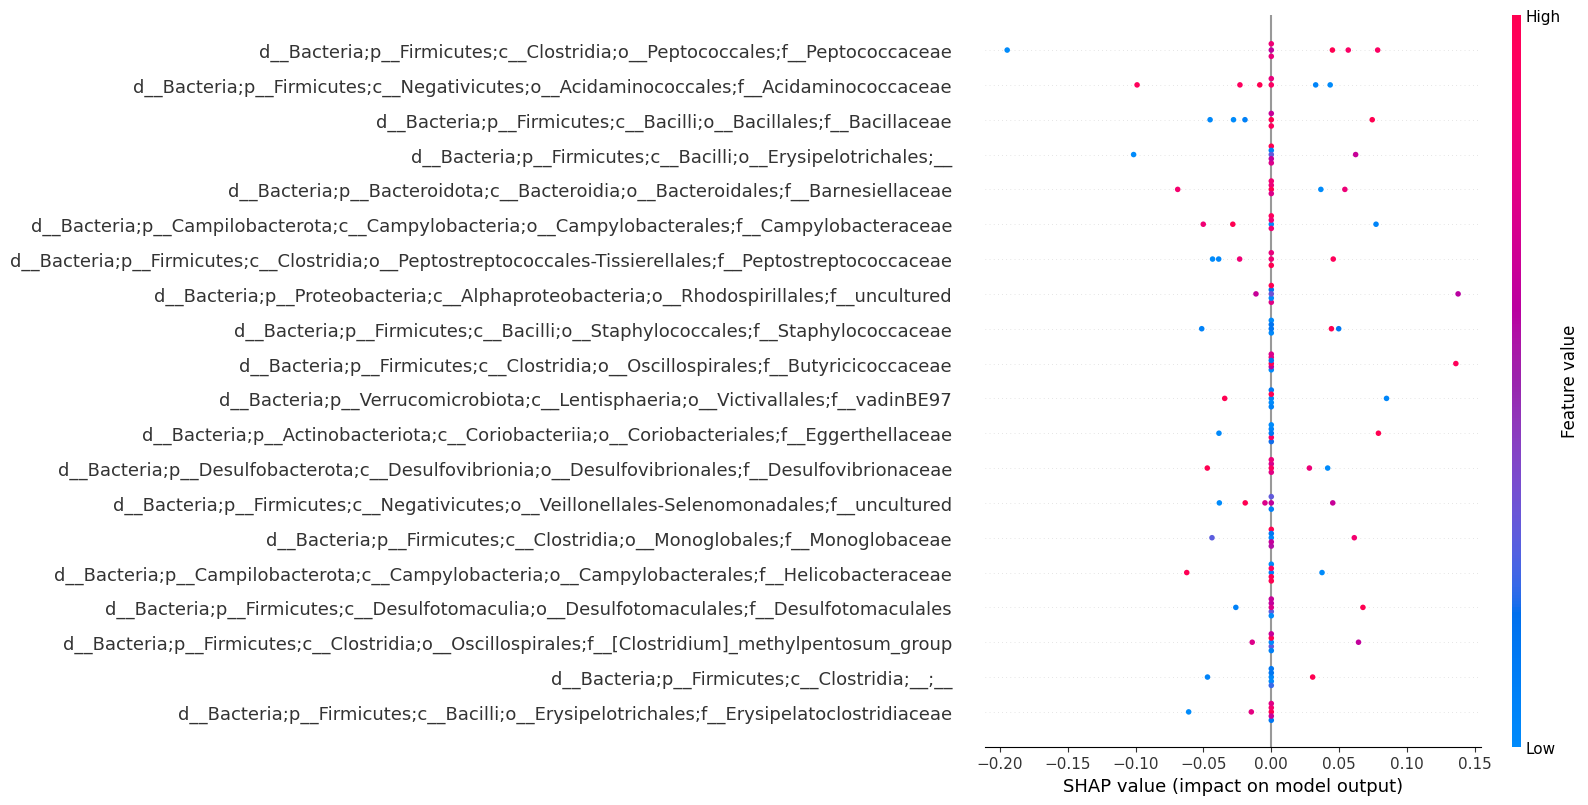


Top 20 taxa by SHAP magnitude with direction (final fold):
                                              feature  mean_abs_shap  \
24  d__Bacteria;p__Firmicutes;c__Clostridia;o__Pep...       0.053503   
2   d__Bacteria;p__Firmicutes;c__Negativicutes;o__...       0.029497   
9   d__Bacteria;p__Firmicutes;c__Bacilli;o__Bacill...       0.023803   
25  d__Bacteria;p__Firmicutes;c__Bacilli;o__Erysip...       0.023359   
28  d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...       0.022802   
38  d__Bacteria;p__Campilobacterota;c__Campylobact...       0.022226   
23  d__Bacteria;p__Firmicutes;c__Clostridia;o__Pep...       0.021564   
19  d__Bacteria;p__Proteobacteria;c__Alphaproteoba...       0.021265   
20  d__Bacteria;p__Firmicutes;c__Bacilli;o__Staphy...       0.020736   
4   d__Bacteria;p__Firmicutes;c__Clostridia;o__Osc...       0.019417   
13  d__Bacteria;p__Verrucomicrobiota;c__Lentisphae...       0.017025   
17  d__Bacteria;p__Actinobacteriota;c__Coriobacter...       0.016776   
18  

In [ ]:
# ======================
# SHAP analysis for final fold
# ======================

# 1) Background set for KernelExplainer
background_size = min(10, last_X_test_scaled.shape[0])
background = last_X_test_scaled[:background_size]


# 2) Prediction wrapper (same as before)
def model_predict(x):
    x = np.array(x, dtype=np.float32)
    return last_model.predict(x, verbose=0).ravel()

# 3) Build explainer
explainer = shap.KernelExplainer(model_predict, background)

# 4) Choose a subset of test samples to explain
n_explain = min(8, last_X_test_scaled.shape[0])
X_explain = last_X_test_scaled[:n_explain]
y_explain = last_y_test[:n_explain]   # labels for those samples

# 5) Compute SHAP values
shap_values = explainer.shap_values(X_explain, nsamples=100)

# Handle list vs array
if isinstance(shap_values, list):
    shap_values_arr = np.array(shap_values[0])
else:
    shap_values_arr = np.array(shap_values)

# 6) Standard SHAP summary plot (directional)
shap.summary_plot(
    shap_values_arr,
    X_explain,
    feature_names=last_feature_names,
    show=True
)

# 7) Magnitude of importance (same as before)
mean_abs_shap = np.abs(shap_values_arr).mean(axis=0)

# 8) Direction of effect: mean signed SHAP overall and by class
mean_shap_overall = shap_values_arr.mean(axis=0)

# make sure you have labels 0 = light, 1 = heavy
heavy_mask = (y_explain == 1)
light_mask = (y_explain == 0)

# handle the case where one class might be absent in first n_explain samples
if heavy_mask.sum() > 0:
    mean_shap_heavy = shap_values_arr[heavy_mask].mean(axis=0)
else:
    mean_shap_heavy = np.full_like(mean_abs_shap, np.nan, dtype=float)

if light_mask.sum() > 0:
    mean_shap_light = shap_values_arr[light_mask].mean(axis=0)
else:
    mean_shap_light = np.full_like(mean_abs_shap, np.nan, dtype=float)

# 9) Combine into one DataFrame
shap_dir_df = pd.DataFrame({
    "feature": last_feature_names,
    "mean_abs_shap": mean_abs_shap,
    "mean_shap_overall": mean_shap_overall,
    "mean_shap_heavy": mean_shap_heavy,
    "mean_shap_light": mean_shap_light
}).sort_values("mean_abs_shap", ascending=False)

print("\nTop 20 taxa by SHAP magnitude with direction (final fold):")
print(shap_dir_df.head(20))

# 10) Simple interpretation: which way does each taxon push?
top = shap_dir_df.head(20).copy()

# direction label based on mean_shap_heavy (you can refine this rule if needed)
def interpret_direction(row):
    if np.isnan(row["mean_shap_heavy"]):
        return "unknown"
    return "heavy" if row["mean_shap_heavy"] > 0 else "light"

top["direction_heavy_vs_light"] = top.apply(interpret_direction, axis=1)

print("\nTop 20 taxa with direction (positive = towards heavy, negative = towards light):")
print(top[["feature", "mean_abs_shap", "mean_shap_heavy", "mean_shap_light",
           "direction_heavy_vs_light"]])

In [ ]:
#background_size = min(10, last_X_test_scaled.shape[0])
#background = last_X_test_scaled[:background_size]

# prediction wrapper
#def model_predict(x):
    #x = np.array(x, dtype=np.float32)
    #return last_model.predict(x, verbose=0).ravel()

#explainer = shap.KernelExplainer(model_predict, background)

# explain a few samples to keep runtime manageable
#n_explain = min(8, last_X_test_scaled.shape[0])
#X_explain = last_X_test_scaled[:n_explain]

#shap_values = explainer.shap_values(X_explain, nsamples=100)

# shap_values may come as list or array depending on SHAP version
#if isinstance(shap_values, list):
    #shap_values_arr = np.array(shap_values[0])
#else:
    #shap_values_arr = np.array(shap_values)

# summary plot
#shap.summary_plot(
    #shap_values_arr,
    #X_explain,
    #feature_names=last_feature_names,
    #show=True
#)

# mean absolute SHAP importance
#mean_abs_shap = np.abs(shap_values_arr).mean(axis=0)
#shap_importance_df = pd.DataFrame({
    #"feature": last_feature_names,
    #"mean_abs_shap": mean_abs_shap
#}).sort_values("mean_abs_shap", ascending=False)

#print("\nTop SHAP-important taxa (final fold):")
#print(shap_importance_df.head(20))

# bar plot of top SHAP features
#top_shap = shap_importance_df.head(15).iloc[::-1]

#plt.figure(figsize=(8, 6))
#plt.barh(top_shap["feature"], top_shap["mean_abs_shap"])
#plt.xlabel("Mean |SHAP value|")
#plt.title("Top 15 SHAP-important taxa (final fold)")
#plt.tight_layout()
#plt.show()

Compare against simpler model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
# X_df: DataFrame of microbiota features (raw counts)
# y: 1D numpy array of labels

def microbiome_preprocess_train_test(X_train_raw, X_test_raw):
    # Relative abundance
    X_train_rel = X_train_raw.div(X_train_raw.sum(axis=1), axis=0)
    X_test_rel  = X_test_raw.div(X_test_raw.sum(axis=1), axis=0)

    # Filtering
    occurrence = (X_train_rel > 0).sum(axis=0) / X_train_rel.shape[0]
    mean_abundance = X_train_rel.mean(axis=0)
    mask = ~((occurrence < 0.05) & (mean_abundance < 0.0001))

    X_train_filt = X_train_rel.loc[:, mask]
    X_test_filt  = X_test_rel.loc[:, mask]

    # CLR
    X_train_pseudo = X_train_filt + 1e-6
    X_test_pseudo  = X_test_filt + 1e-6

    gm_train = gmean(X_train_pseudo, axis=1)
    gm_test  = gmean(X_test_pseudo, axis=1)

    X_train_clr = np.log(X_train_pseudo.div(gm_train, axis=0))
    X_test_clr  = np.log(X_test_pseudo.div(gm_test, axis=0))

    return X_train_clr, X_test_clr

In [ ]:
def evaluate_simple_models_kfold(X_df, y, k=5, seed=42):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)

    results = {
        "LR": [],
        "SVM": [],
        "RF": [],
        "NN": []
    }

    fold = 1
    for train_idx, test_idx in skf.split(X_df, y):
        print(f"\n=== Fold {fold} ===")
        fold += 1

        X_train_raw = X_df.iloc[train_idx].copy()
        X_test_raw  = X_df.iloc[test_idx].copy()
        y_train = y[train_idx]
        y_test  = y[test_idx]

        # Preprocess (relative abundance, filter, CLR)
        X_train_clr, X_test_clr = microbiome_preprocess_train_test(X_train_raw, X_test_raw)

        # RF feature selection as before
        rf_fs = RandomForestClassifier(
            n_estimators=500,
            random_state=seed
        )
        rf_fs.fit(X_train_clr, y_train)
        importances = pd.Series(rf_fs.feature_importances_, index=X_train_clr.columns)
        importances_sorted = importances.sort_values(ascending=False)
        # Select taxa explaining ≥ 90% of RF importance
        cum_frac = importances_sorted.cumsum() / importances_sorted.sum()
        top_n_count = np.searchsorted(cum_frac.values, 0.90) + 1
        print(f"Fold {fold}: selected {top_n_count} taxa to reach 90% RF importance.")

        top_features = importances_sorted.head(top_n_count).index

        X_train_top = X_train_clr.loc[:, top_features]
        X_test_top  = X_test_clr.loc[:, top_features]

        # Standardization
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_top)
        X_test_scaled  = scaler.transform(X_test_top)

        # 1) Logistic Regression
        lr = LogisticRegression(
            penalty="l2",
            solver="liblinear",
            random_state=seed
        )
        lr.fit(X_train_scaled, y_train)
        y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
        y_pred_lr = (y_prob_lr >= 0.5).astype(int)

        results["LR"].append({
            "accuracy": accuracy_score(y_test, y_pred_lr),
            "roc_auc": roc_auc_score(y_test, y_prob_lr),
            "precision": precision_score(y_test, y_pred_lr, zero_division=0),
            "recall": recall_score(y_test, y_pred_lr, zero_division=0),
            "f1": f1_score(y_test, y_pred_lr, zero_division=0)
        })

        # 2) Linear SVM (probabilities via Platt scaling)
        svm = SVC(
            kernel="linear",
            probability=True,
            random_state=seed
        )
        svm.fit(X_train_scaled, y_train)
        y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]
        y_pred_svm = (y_prob_svm >= 0.5).astype(int)

        results["SVM"].append({
            "accuracy": accuracy_score(y_test, y_pred_svm),
            "roc_auc": roc_auc_score(y_test, y_prob_svm),
            "precision": precision_score(y_test, y_pred_svm, zero_division=0),
            "recall": recall_score(y_test, y_pred_svm, zero_division=0),
            "f1": f1_score(y_test, y_pred_svm, zero_division=0)
        })

        # 3) Random Forest classifier on CLR+top features
        rf_clf = RandomForestClassifier(
            n_estimators=500,
            random_state=seed
        )
        rf_clf.fit(X_train_top, y_train)
        y_prob_rf = rf_clf.predict_proba(X_test_top)[:, 1]
        y_pred_rf = (y_prob_rf >= 0.5).astype(int)

        results["RF"].append({
            "accuracy": accuracy_score(y_test, y_pred_rf),
            "roc_auc": roc_auc_score(y_test, y_prob_rf),
            "precision": precision_score(y_test, y_pred_rf, zero_division=0),
            "recall": recall_score(y_test, y_pred_rf, zero_division=0),
            "f1": f1_score(y_test, y_pred_rf, zero_division=0)
        })

        # 4) NN — re-use your build_model
        # inner split for early stopping
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train_scaled,
            y_train,
            test_size=0.2,
            random_state=seed,
            stratify=y_train
        )

        nn_model = build_model(input_dim=X_tr.shape[1])
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=12,
            restore_best_weights=True
        )
        nn_model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=70,
            batch_size=8,
            callbacks=[early_stop],
            verbose=0
        )

        y_prob_nn = nn_model.predict(X_test_scaled, verbose=0).ravel()
        y_pred_nn = (y_prob_nn >= 0.5).astype(int)

        results["NN"].append({
            "accuracy": accuracy_score(y_test, y_pred_nn),
            "roc_auc": roc_auc_score(y_test, y_prob_nn),
            "precision": precision_score(y_test, y_pred_nn, zero_division=0),
            "recall": recall_score(y_test, y_pred_nn, zero_division=0),
            "f1": f1_score(y_test, y_pred_nn, zero_division=0)
        })

    # summarize
    summary = {}
    for model_name, scores in results.items():
        df = pd.DataFrame(scores)
        summary[model_name] = {
            "mean": df.mean().round(3),
            "std": df.std(ddof=1).round(3)
        }

    return results, summary



In [ ]:
# Run the comparison
results, summary = evaluate_simple_models_kfold(X_df, y, k=5, seed=42)

print("\n=== Mean ± SD across folds ===")
for model_name, stats in summary.items():
    print(f"\n{model_name}:")
    print("Mean:")
    print(stats["mean"])
    print("SD:")
    print(stats["std"])


=== Fold 1 ===
Fold 2: selected 34 taxa to reach 90% RF importance.

=== Fold 2 ===
Fold 3: selected 34 taxa to reach 90% RF importance.

=== Fold 3 ===
Fold 4: selected 37 taxa to reach 90% RF importance.

=== Fold 4 ===
Fold 5: selected 35 taxa to reach 90% RF importance.

=== Fold 5 ===
Fold 6: selected 39 taxa to reach 90% RF importance.

=== Mean ± SD across folds ===

LR:
Mean:
accuracy     0.975
roc_auc      0.988
precision    0.960
recall       1.000
f1           0.978
dtype: float64
SD:
accuracy     0.056
roc_auc      0.028
precision    0.089
recall       0.000
f1           0.050
dtype: float64

SVM:
Mean:
accuracy     0.975
roc_auc      0.988
precision    0.960
recall       1.000
f1           0.978
dtype: float64
SD:
accuracy     0.056
roc_auc      0.028
precision    0.089
recall       0.000
f1           0.050
dtype: float64

RF:
Mean:
accuracy     0.925
roc_auc      0.975
precision    0.920
recall       0.950
f1           0.927
dtype: float64
SD:
accuracy     0.068
roc_auc 